<a href="https://colab.research.google.com/github/kallydimitrova/HEPexercises/blob/main/Exercise6_IceCube.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import json
import numpy as np
import pandas as pd

def load_hese_data(path):
    with open(path) as f:
        raw = json.load(f)

    required = ["recoDepositedEnergy", "recoMorphology", "recoZenith", "recoLength"]
    missing = [k for k in required if k not in raw]
    if missing:
        raise ValueError(f"{path} is missing expected key(s) {missing}; "
                          f"keys found: {list(raw.keys())}")

    df = pd.DataFrame({
        "E_GeV": raw["recoDepositedEnergy"],
        "morphology": raw["recoMorphology"],
        "zenith_rad": raw["recoZenith"],
        "length_m": raw["recoLength"],
    })

    if (df["E_GeV"] < 0).any():
        raise ValueError(f"Negative deposited energy found in {path}.")

    df["E_TeV"] = df["E_GeV"] / 1000.0
    df["zenith_deg"] = np.degrees(df["zenith_rad"])
    # Declination from zenith angle alone -- valid only for a detector at the south pole
    df["dec_deg"] = df["zenith_deg"] - 90.0

    morph_label = {0: "cascade", 1: "track", 2: "double_cascade"}
    df["morphology_label"] = df["morphology"].map(morph_label)

    return df

events = load_hese_data("data/HESE_data.json")
print(f"Loaded {len(events)} events; columns: {list(events.columns)}")

Loaded 102 events; columns: ['E_GeV', 'morphology', 'zenith_rad', 'length_m', 'E_TeV', 'zenith_deg', 'dec_deg', 'morphology_label']


In [2]:
print(events[["E_GeV", "E_TeV", "morphology_label", "zenith_deg", "dec_deg"]].head())
print(events["morphology_label"].value_counts())
print(events["length_m"].describe())

           E_GeV       E_TeV morphology_label  zenith_deg    dec_deg
0   40094.570312   40.094570          cascade  104.683420  14.683420
1   98474.578125   98.474578          cascade   81.516081  -8.483919
2   70592.507812   70.592508            track   54.732652 -35.267348
3  184547.453125  184.547453          cascade   52.293130 -37.706870
4   27220.697266   27.220697          cascade   70.826132 -19.173868
morphology_label
cascade           71
track             27
double_cascade     4
Name: count, dtype: int64
count     4.000000
mean     15.400652
std       3.345496
min      10.550351
25%      14.815658
50%      16.419739
75%      17.004733
max      18.212780
Name: length_m, dtype: float64


In [3]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 12,
    "font.family": "serif",
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "figure.dpi": 150,
    "savefig.bbox": "tight",
})

In [4]:
def inspect_catalogue(events):
    print(f"Number of events:        {len(events)}")
    print(f"Minimum deposited energy: {events['E_TeV'].min():.2f} TeV")
    print(f"Maximum deposited energy: {events['E_TeV'].max():.2f} TeV")
    counts = events["morphology_label"].value_counts()
    for label in ("cascade", "track", "double_cascade"):
        print(f"  {label:15s}: {counts.get(label, 0)}")

inspect_catalogue(events)

Number of events:        102
Minimum deposited energy: 19.91 TeV
Maximum deposited energy: 1799.98 TeV
  cascade        : 71
  track          : 27
  double_cascade : 4


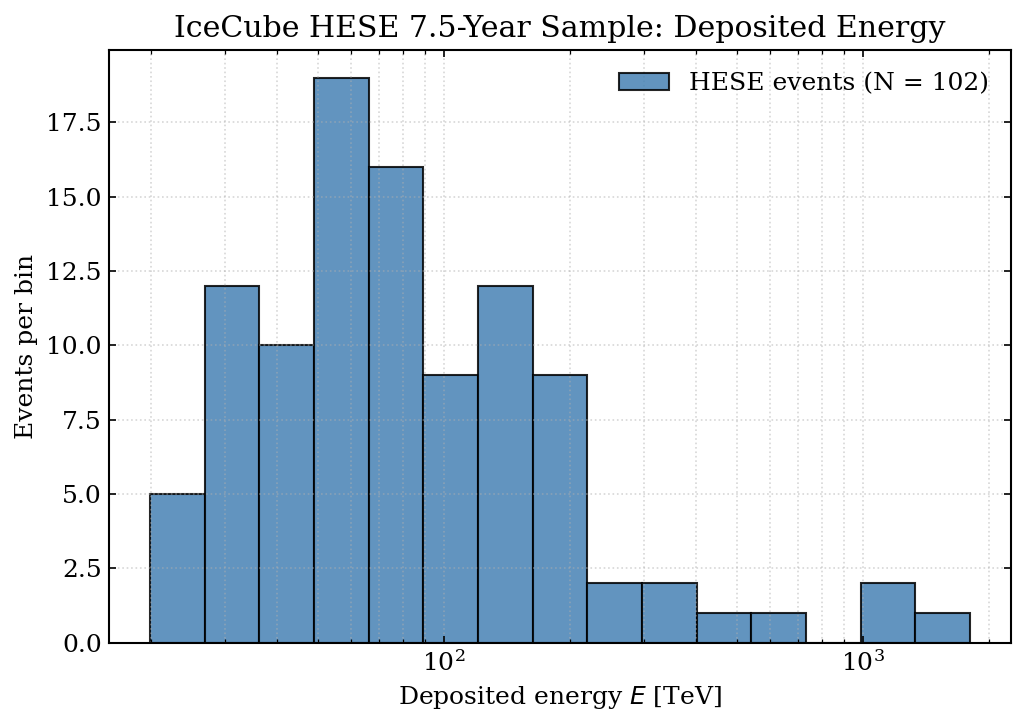

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

n_bins = 15
bins = np.logspace(np.log10(events["E_TeV"].min()),
                    np.log10(events["E_TeV"].max()), n_bins + 1)

ax.hist(events["E_TeV"], bins=bins, color="steelblue", edgecolor="black",
        alpha=0.85, label=f"HESE events (N = {len(events)})")

ax.set_xscale("log")
ax.set_xlabel("Deposited energy $E$ [TeV]")
ax.set_ylabel("Events per bin")
ax.set_title("IceCube HESE 7.5-Year Sample: Deposited Energy")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend()
fig.tight_layout()
fig.savefig("figures/energy_histogram.png", dpi=300)

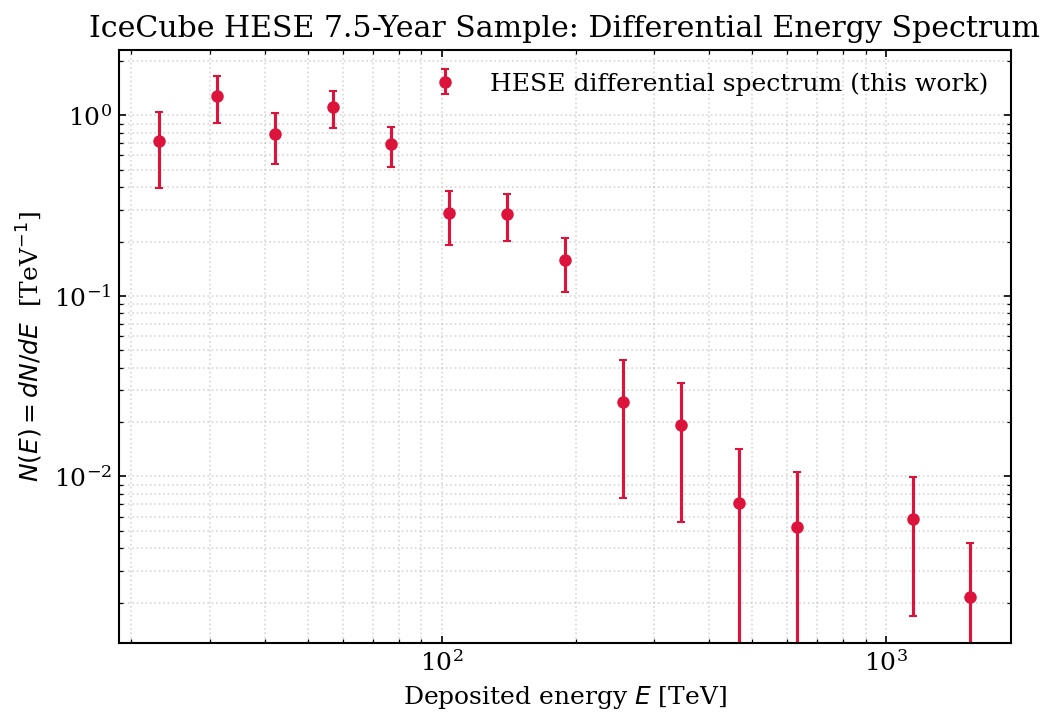

In [7]:
def differential_spectrum(E_values, n_bins=15, E_min=None, E_max=None):
    E_min = E_values.min() if E_min is None else E_min
    E_max = E_values.max() if E_max is None else E_max
    bin_edges = np.logspace(np.log10(E_min), np.log10(E_max), n_bins + 1)

    counts, edges = np.histogram(E_values, bins=bin_edges)
    widths = edges[1:] - edges[:-1]
    centers = np.sqrt(edges[:-1] * edges[1:])
    dNdE = counts / widths
    dNdE_err = np.sqrt(counts) / widths
    return centers, dNdE, dNdE_err, counts

E_centers, dNdE, dNdE_err, counts = differential_spectrum(events["E_TeV"].values)

fig, ax = plt.subplots(figsize=(7, 5))
mask = counts > 0  # log-log plotting cannot show empty bins
ax.errorbar(E_centers[mask], dNdE[mask], yerr=dNdE_err[mask],
            fmt="o", color="crimson", ecolor="crimson", markersize=5, capsize=2,
            label="HESE differential spectrum (this work)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Deposited energy $E$ [TeV]")
ax.set_ylabel(r"$N(E) = dN/dE$  [TeV$^{-1}$]")
ax.set_title("IceCube HESE 7.5-Year Sample: Differential Energy Spectrum")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend()
fig.tight_layout()
fig.savefig("figures/differential_spectrum.png", dpi=300)

Fitted spectral index: gamma = 1.98 +/- 0.19


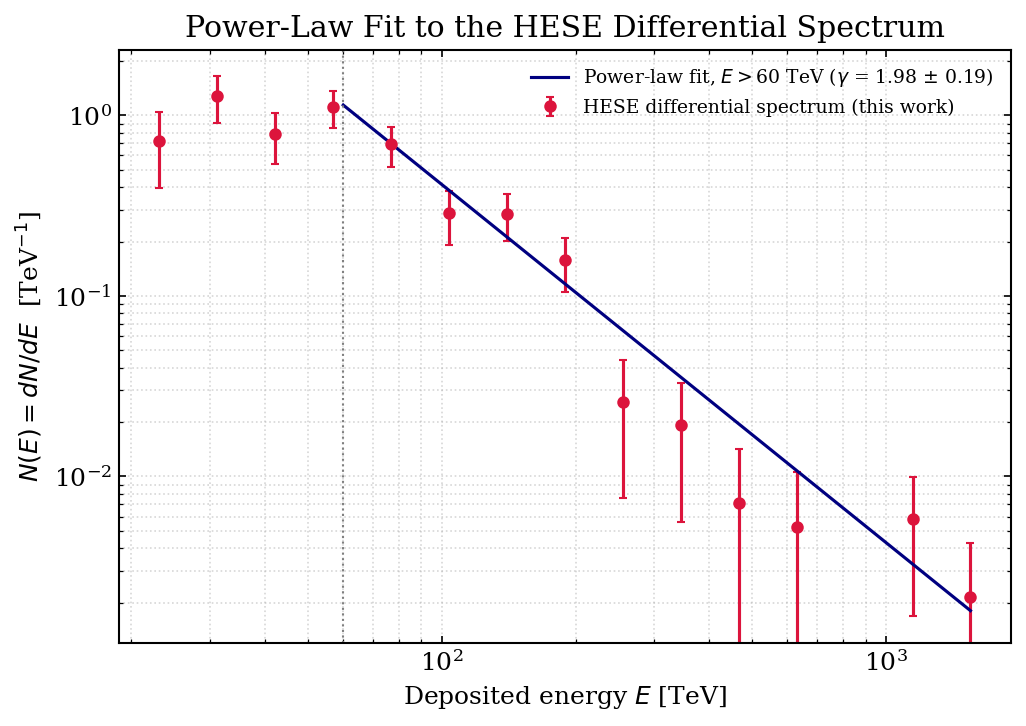

In [8]:
from scipy.optimize import curve_fit

def fit_power_law(E, dNdE, dNdE_err, E0=100.0):
    def model(E, logA, gamma):
        return logA - gamma * np.log10(E / E0)

    log_dNdE = np.log10(dNdE)
    log_err = dNdE_err / (dNdE * np.log(10))

    popt, pcov = curve_fit(model, E, log_dNdE, sigma=log_err,
                            p0=[np.log10(dNdE[0]), 2.5], absolute_sigma=True)
    perr = np.sqrt(np.diag(pcov))
    A = 10**popt[0]
    return {"A": A, "gamma": popt[1], "gamma_err": perr[1]}

# Restrict the fit to the region used in the official 7.5-year analysis
E_THRESHOLD_TEV = 60.0
fit_mask = (E_centers >= E_THRESHOLD_TEV) & (counts > 0)

res = fit_power_law(E_centers[fit_mask], dNdE[fit_mask], dNdE_err[fit_mask])
print(f"Fitted spectral index: gamma = {res['gamma']:.2f} +/- {res['gamma_err']:.2f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(E_centers[mask], dNdE[mask], yerr=dNdE_err[mask],
            fmt="o", color="crimson", ecolor="crimson", markersize=5, capsize=2,
            label="HESE differential spectrum (this work)")

E_fine = np.logspace(np.log10(E_THRESHOLD_TEV), np.log10(E_centers.max()), 200)
def power_law(E, A, gamma, E0=100.0):
    return A * (E / E0)**(-gamma)
ax.plot(E_fine, power_law(E_fine, res["A"], res["gamma"]), "-", color="navy",
        linewidth=1.5,
        label=fr"Power-law fit, $E>${E_THRESHOLD_TEV:.0f} TeV "
              fr"($\gamma$ = {res['gamma']:.2f} $\pm$ {res['gamma_err']:.2f})")
ax.axvline(E_THRESHOLD_TEV, color="gray", linestyle=":", linewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Deposited energy $E$ [TeV]")
ax.set_ylabel(r"$N(E) = dN/dE$  [TeV$^{-1}$]")
ax.set_title("Power-Law Fit to the HESE Differential Spectrum")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig("figures/spectrum_fit.png", dpi=300)

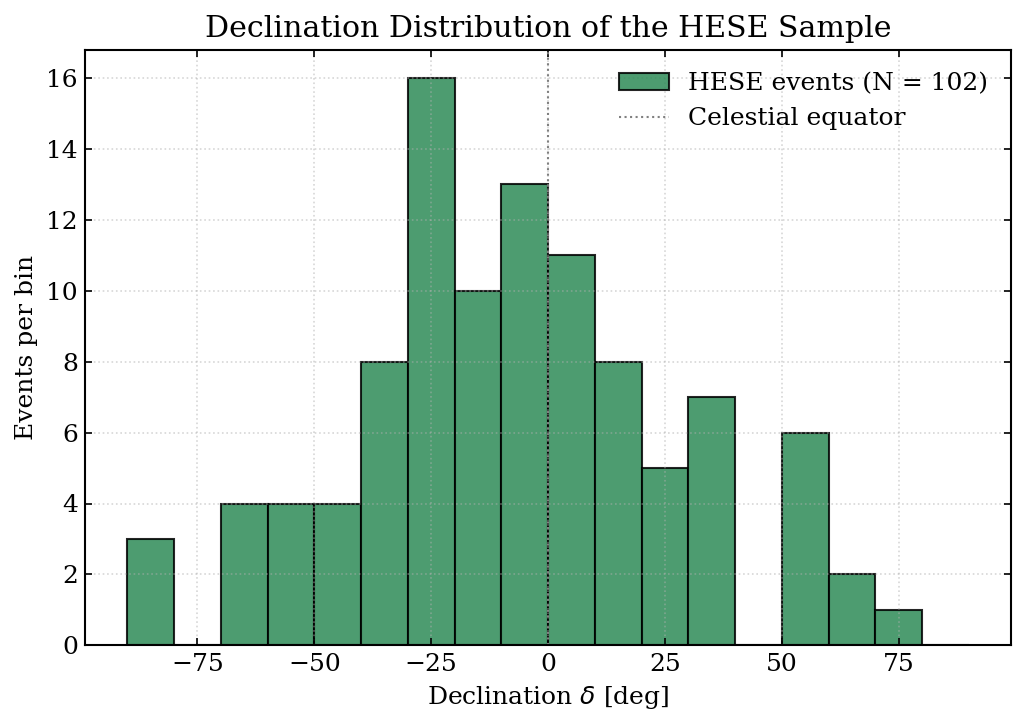

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(events["dec_deg"], bins=18, range=(-90, 90), color="seagreen",
        edgecolor="black", alpha=0.85, label=f"HESE events (N = {len(events)})")

ax.axvline(0, color="gray", linestyle=":", linewidth=1, label="Celestial equator")
ax.set_xlabel(r"Declination $\delta$ [deg]")
ax.set_ylabel("Events per bin")
ax.set_title("Declination Distribution of the HESE Sample")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend()
fig.tight_layout()
fig.savefig("figures/declination_distribution.png", dpi=300)

KS statistic = 0.145, p-value = 0.024


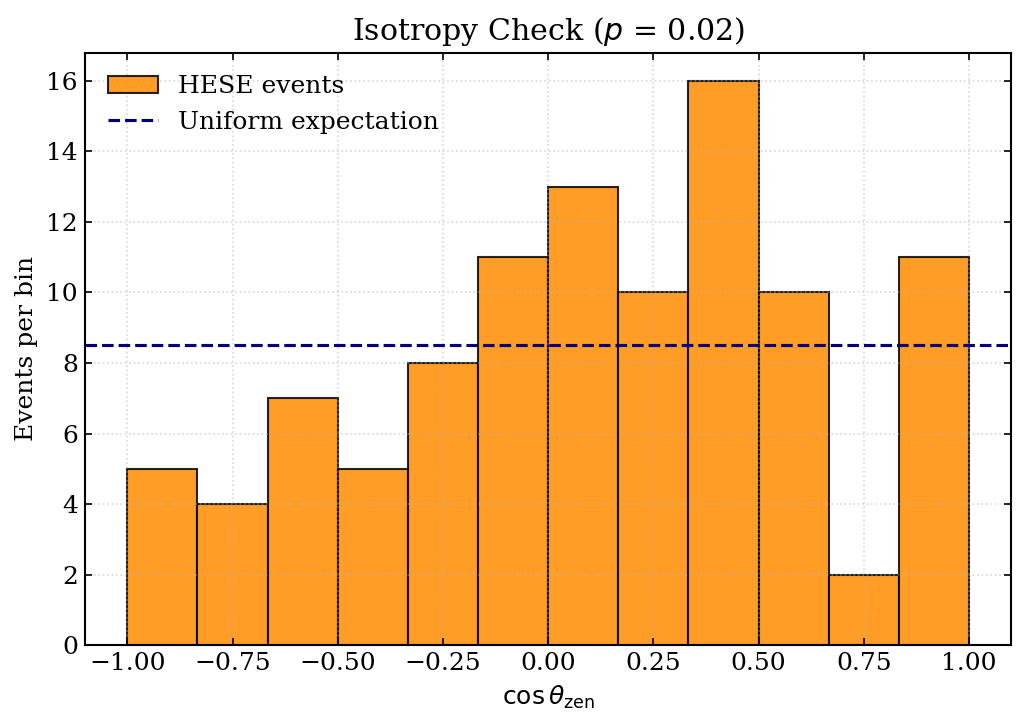

In [11]:
from scipy import stats

def isotropy_test(events):
    cos_zenith = np.cos(events["zenith_rad"].values)
    ks_stat, p_value = stats.kstest(cos_zenith, "uniform", args=(-1, 2))
    return ks_stat, p_value

ks_stat, p_value = isotropy_test(events)
print(f"KS statistic = {ks_stat:.3f}, p-value = {p_value:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(np.cos(events["zenith_rad"]), bins=12, range=(-1, 1), color="darkorange",
        edgecolor="black", alpha=0.85, label="HESE events")
ax.axhline(len(events) / 12, color="navy", linestyle="--", linewidth=1.5,
           label="Uniform expectation")
ax.set_xlabel(r"$\cos\theta_{\rm zen}$")
ax.set_ylabel("Events per bin")
ax.set_title(fr"Isotropy Check ($p$ = {p_value:.2f})")
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend()
fig.tight_layout()
fig.savefig("figures/isotropy_test.png", dpi=300)

  cascade        :  71  (69.6%)
  track          :  27  (26.5%)
  double_cascade :   4  (3.9%)


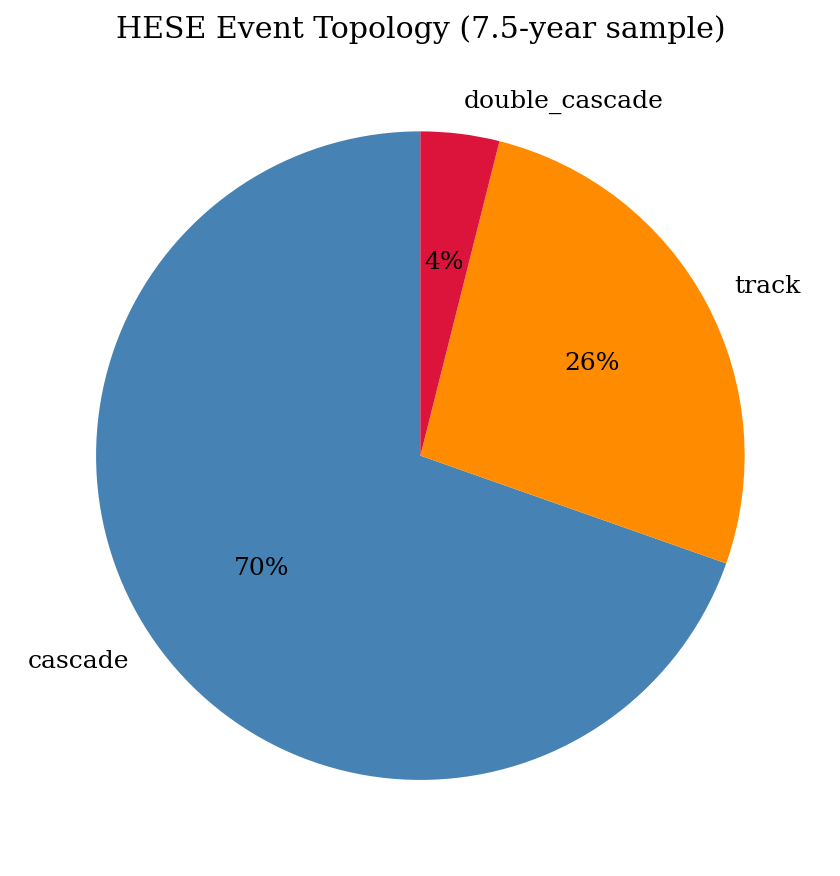

In [12]:
def topology_fractions(events):
    counts = events["morphology_label"].value_counts()
    fractions = counts / len(events)
    for label in ("cascade", "track", "double_cascade"):
        print(f"  {label:15s}: {counts.get(label, 0):3d}  "
              f"({100 * fractions.get(label, 0.0):.1f}%)")
    return fractions

fractions = topology_fractions(events)

fig, ax = plt.subplots(figsize=(6, 6))
counts = events["morphology_label"].value_counts()
colors = {"cascade": "steelblue", "track": "darkorange", "double_cascade": "crimson"}
ax.pie(counts.values, labels=counts.index,
       autopct="%1.0f%%", colors=[colors[c] for c in counts.index],
       startangle=90)
ax.set_title("HESE Event Topology (7.5-year sample)")
fig.tight_layout()
fig.savefig("figures/topology_fractions.png", dpi=300)

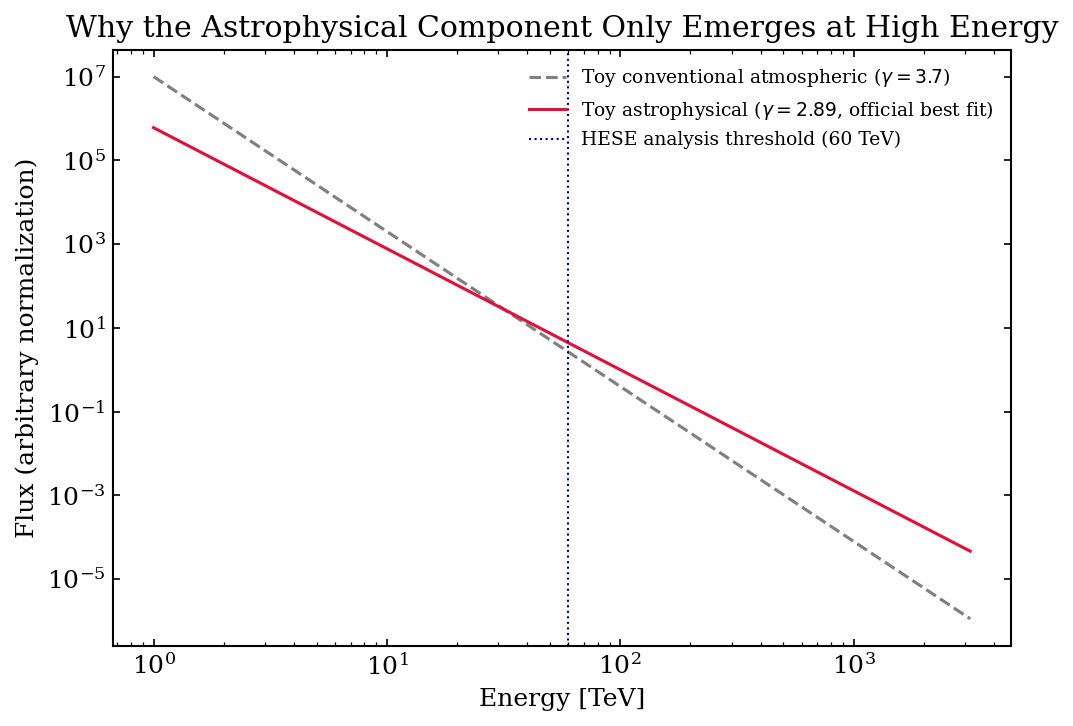

In [13]:
def toy_atmospheric(E, A_atm=1.0e7, gamma_atm=3.7):
    return A_atm * E**(-gamma_atm)

def toy_astrophysical(E, A_astro=1.0, gamma_astro=2.89):
    return A_astro * (E / 100.0)**(-gamma_astro)

E_grid = np.logspace(0, 3.5, 200)
atm = toy_atmospheric(E_grid)
astro = toy_astrophysical(E_grid)

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(E_grid, atm, "--", color="gray", label=r"Toy conventional atmospheric ($\gamma=3.7$)")
ax.loglog(E_grid, astro, "-", color="crimson",
          label=r"Toy astrophysical ($\gamma=2.89$, official best fit)")
ax.axvline(60.0, color="navy", linestyle=":", linewidth=1, label="HESE analysis threshold (60 TeV)")
ax.set_xlabel("Energy [TeV]")
ax.set_ylabel("Flux (arbitrary normalization)")
ax.set_title("Why the Astrophysical Component Only Emerges at High Energy")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig("figures/toy_atmospheric_vs_astro.png", dpi=300)